# Phase 2: Subterranean Thermal Reservoir Mapping (var2)
## BT2024195 — Polynomial Regression Assignment (Improved: ElasticNet)

**Objective:** Predict **Thermal Anomaly Score (y)** at 3D spatial coordinate offsets.

**Features:** x1 (E-W), x2 (N-S), x3 (depth)  
**Target:** y = Thermal Anomaly Score (high-degree polynomial, up to degree 20)

**Improvements over baseline:**
- ElasticNet: CV decides optimal Ridge/Lasso blend (crucial for high-degree poly features)
- Fine alpha search via `np.logspace` (50 values)
- Grid search over `l1_ratio` — Lasso can zero out irrelevant high-degree cross terms
- 10-fold CV for more reliable estimates

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load and Explore the Datasets

In [2]:
train_df = pd.read_csv('../data/BT2024195_train_var2.csv')
test_df  = pd.read_csv('../data/BT2024195_test_var2.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
print(f'Columns:     {list(train_df.columns)}')

Train shape: (1000, 4)
Test shape:  (1000, 3)
Columns:     ['x1', 'x2', 'x3', 'y']


In [3]:
print('=== Training Data — First 5 rows ===')
display(train_df.head())
print('\n=== Descriptive Statistics ===')
display(train_df.describe())

=== Training Data — First 5 rows ===


,x1,x2,x3,y
0,-1.000000,-0.636444,0.856608,7.162088
1,-0.714261,0.580873,-0.397808,-2.565405
2,0.906014,-1.000000,0.652038,-4.213609
3,-1.000000,0.955547,-0.162822,7.670078
4,1.000000,0.354955,-1.000000,11.111701



=== Descriptive Statistics ===


,x1,x2,x3,y
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.002050,-0.031377,0.011735,2.080735
std,0.673795,0.676668,0.667849,6.617234
min,-1.000000,-1.000000,-1.000000,-29.901549
25%,-0.559938,-0.643292,-0.540239,-0.696639
50%,0.017050,-0.045567,0.025474,1.214342
75%,0.574334,0.542849,0.570476,4.961374
max,1.000000,1.000000,1.000000,32.365485


In [4]:
print('Missing values — Train:')
print(train_df.isnull().sum())
print('\nMissing values — Test:')
print(test_df.isnull().sum())

Missing values — Train:
x1    0
x2    0
x3    0
y     0
dtype: int64

Missing values — Test:
x1    0
x2    0
x3    0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA)

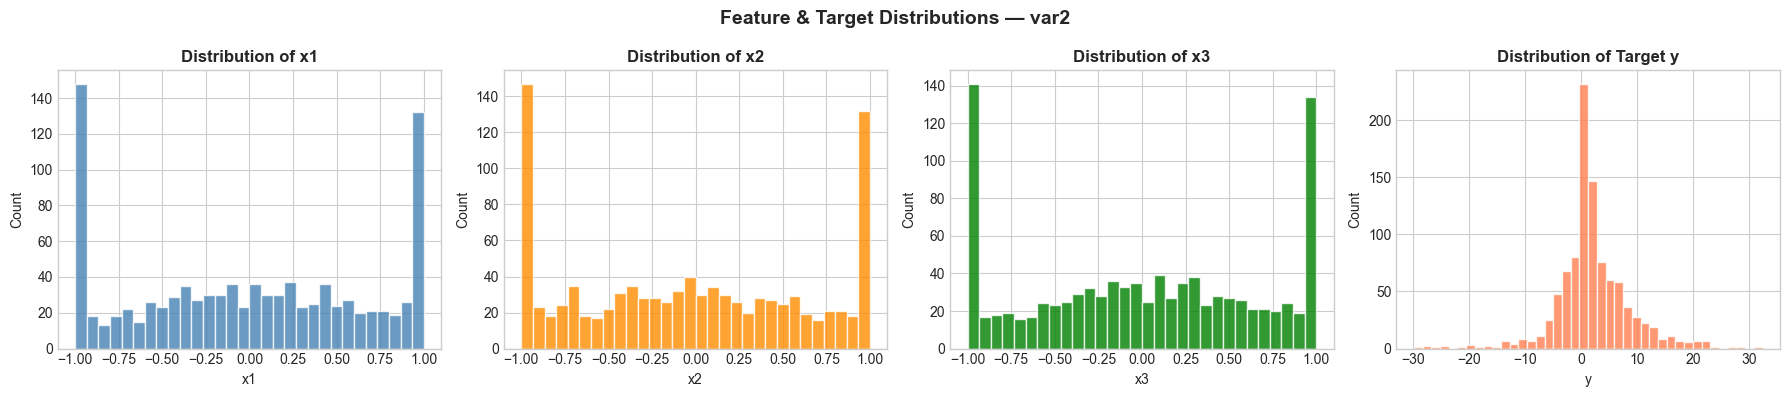

In [5]:
feature_cols = ['x1', 'x2', 'x3']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['steelblue', 'darkorange', 'green', 'coral']
for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
axes[3].hist(train_df['y'], bins=40, color=colors[3], edgecolor='white', alpha=0.8)
axes[3].set_title('Distribution of Target y', fontweight='bold')
axes[3].set_xlabel('y'); axes[3].set_ylabel('Count')
plt.suptitle('Feature & Target Distributions — var2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

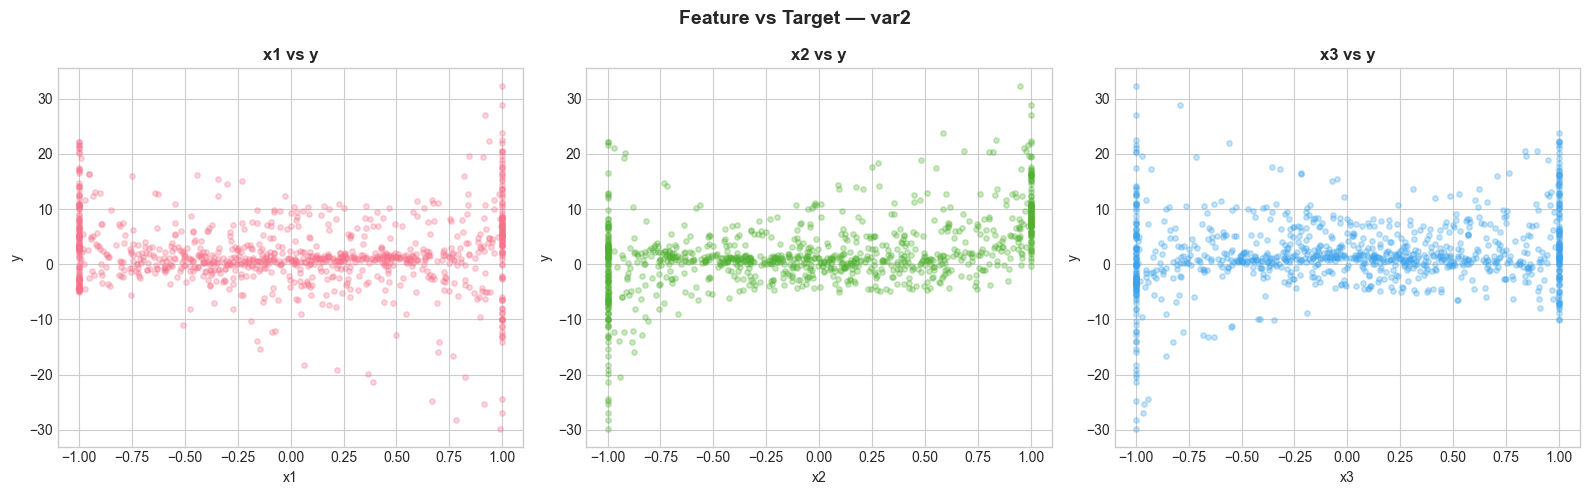

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = sns.color_palette('husl', 3)
for i, col in enumerate(feature_cols):
    axes[i].scatter(train_df[col], train_df['y'], alpha=0.3, color=colors[i], s=15)
    axes[i].set_xlabel(col); axes[i].set_ylabel('y')
    axes[i].set_title(f'{col} vs y', fontweight='bold')
plt.suptitle('Feature vs Target — var2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

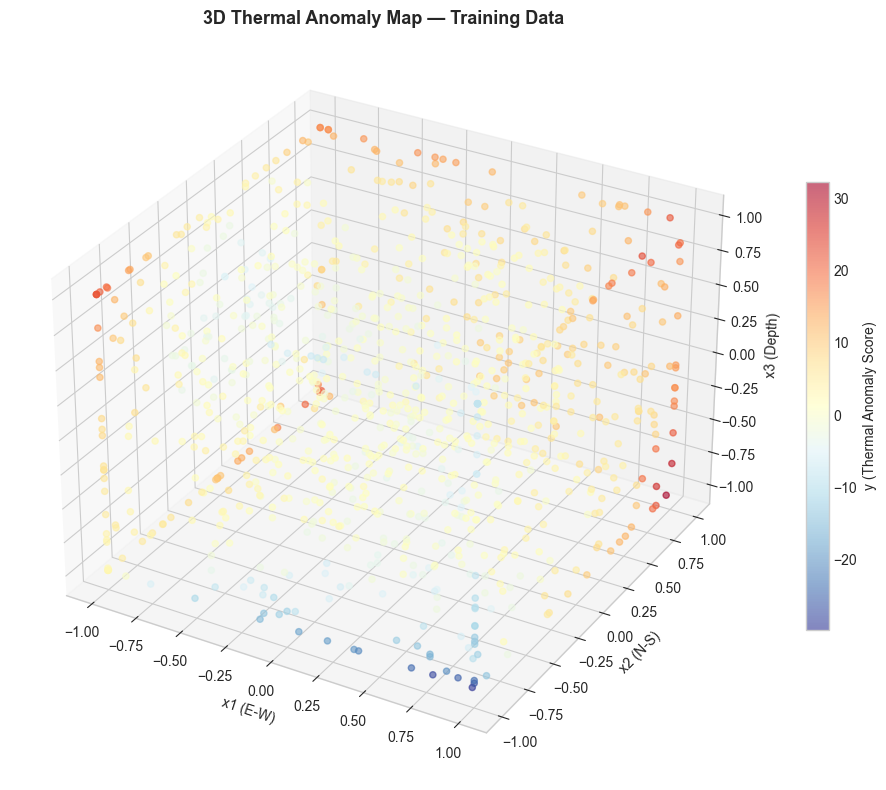

In [7]:
# 3D scatter of training data colored by thermal score
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(train_df['x1'], train_df['x2'], train_df['x3'],
                c=train_df['y'], cmap='RdYlBu_r', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='y (Thermal Anomaly Score)', shrink=0.6)
ax.set_xlabel('x1 (E-W)'); ax.set_ylabel('x2 (N-S)'); ax.set_zlabel('x3 (Depth)')
ax.set_title('3D Thermal Anomaly Map — Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

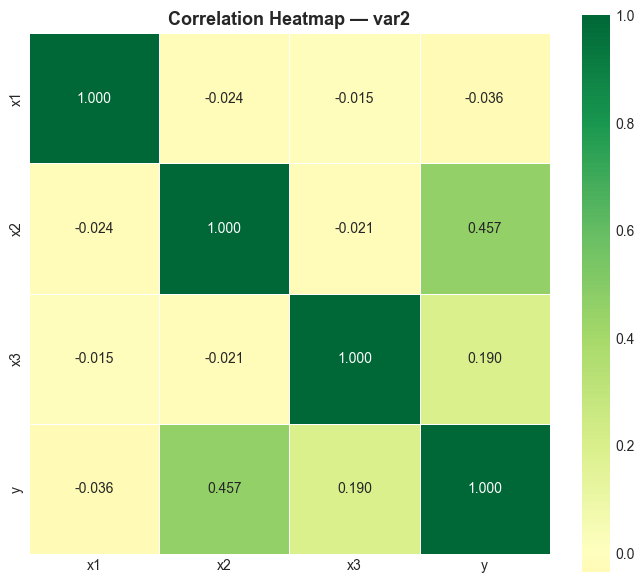

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = train_df.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Heatmap — var2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Prepare Features and Labels

In [9]:
X_train = train_df[feature_cols].values
y_train = train_df['y'].values
X_test  = test_df[feature_cols].values

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}')

X_train: (1000, 3), y_train: (1000,), X_test: (1000, 3)


## Step 5: Degree Selection via 10-Fold Cross-Validation (1–20)

For var2 with 3 features, polynomial features grow as C(d+3, 3). Even at degree 20, the feature count is ~1771 — still tractable. Ridge(alpha=1.0) is used as a fast proxy for degree selection.

In [10]:
degrees = list(range(1, 21))
cv_mse_means, cv_mse_stds, cv_r2_means = [], [], []
n_poly_feats = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"{'Degree':>6} | {'#Poly Feats':>11} | {'CV MSE (mean)':>15} | {'CV R2 (mean)':>13}")
print('-' * 55)

for deg in degrees:
    pf_tmp = PolynomialFeatures(degree=deg, include_bias=False)
    pf_tmp.fit(X_train)
    n_poly_feats.append(pf_tmp.n_output_features_)

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0))
    ])
    mse_scores = -cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    r2_scores  =  cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
    cv_mse_means.append(mse_scores.mean())
    cv_mse_stds.append(mse_scores.std())
    cv_r2_means.append(r2_scores.mean())
    print(f"{deg:>6} | {n_poly_feats[-1]:>11} | {mse_scores.mean():>15.4f} | {r2_scores.mean():>13.4f}")

best_deg_r2  = degrees[np.argmax(cv_r2_means)]
best_deg_mse = degrees[np.argmin(cv_mse_means)]
print(f'\nBest degree by R²:  {best_deg_r2}')
print(f'Best degree by MSE: {best_deg_mse}')

Degree | #Poly Feats |   CV MSE (mean) |  CV R2 (mean)
-------------------------------------------------------
     1 |           3 |         33.3074 |        0.2183
     2 |           9 |         21.0717 |        0.5040
     3 |          19 |         10.2268 |        0.7534
     4 |          34 |          3.1196 |        0.9244
     5 |          55 |          1.3160 |        0.9682
     6 |          83 |          0.5433 |        0.9866
     7 |         119 |          0.3559 |        0.9912
     8 |         164 |          0.2657 |        0.9934
     9 |         219 |          0.2482 |        0.9938
    10 |         285 |          0.2315 |        0.9942
    11 |         363 |          0.2323 |        0.9942
    12 |         454 |          0.2320 |        0.9942
    13 |         559 |          0.2366 |        0.9941
    14 |         679 |          0.2410 |        0.9940
    15 |         815 |          0.2471 |        0.9938
    16 |         968 |          0.2537 |        0.9937
    17 | 

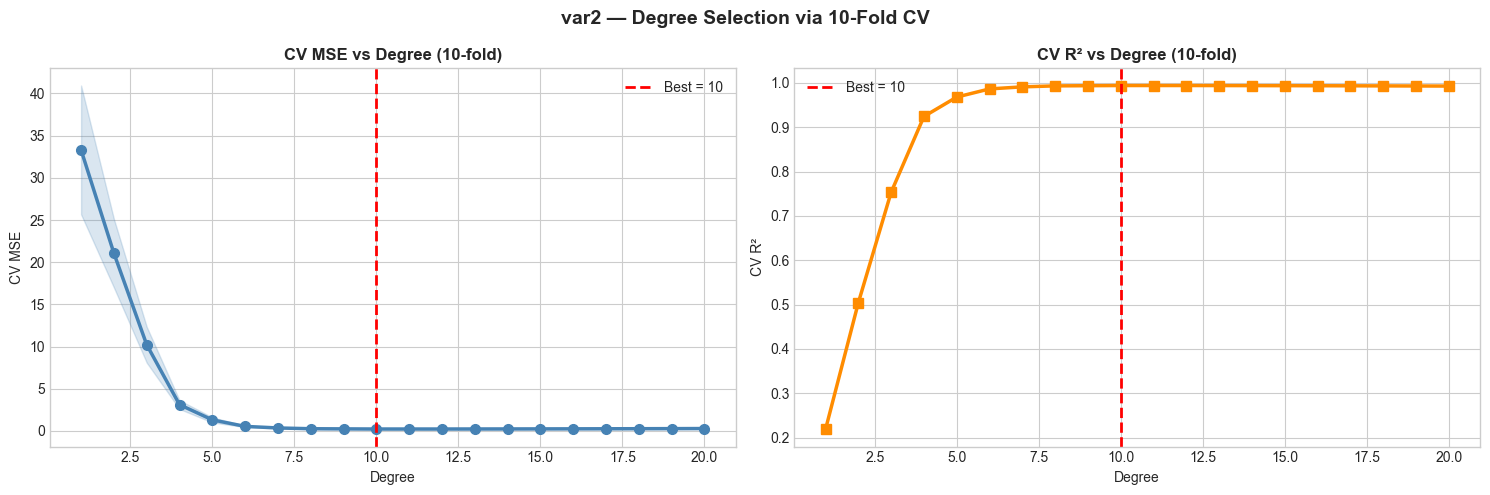

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(degrees, cv_mse_means, 'o-', color='steelblue', lw=2.5, ms=7)
axes[0].fill_between(degrees,
                      np.array(cv_mse_means) - np.array(cv_mse_stds),
                      np.array(cv_mse_means) + np.array(cv_mse_stds),
                      alpha=0.2, color='steelblue')
axes[0].axvline(best_deg_mse, color='red', ls='--', lw=2, label=f'Best = {best_deg_mse}')
axes[0].set_title('CV MSE vs Degree (10-fold)', fontweight='bold')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('CV MSE'); axes[0].legend()

axes[1].plot(degrees, cv_r2_means, 's-', color='darkorange', lw=2.5, ms=7)
axes[1].axvline(best_deg_r2, color='red', ls='--', lw=2, label=f'Best = {best_deg_r2}')
axes[1].set_title('CV R² vs Degree (10-fold)', fontweight='bold')
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('CV R²'); axes[1].legend()

plt.suptitle('var2 — Degree Selection via 10-Fold CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_degree_selection.png', dpi=150, bbox_inches='tight')
plt.show()

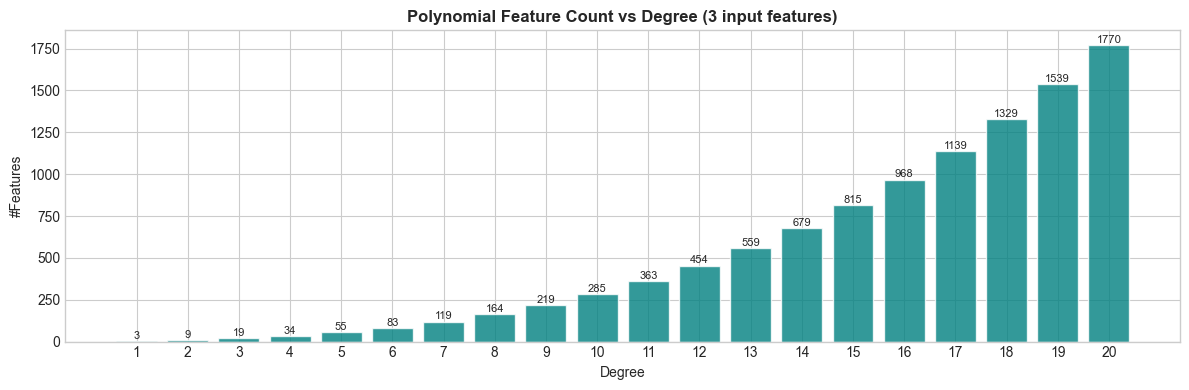

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(degrees, n_poly_feats, color='teal', edgecolor='white', alpha=0.8)
ax.set_title('Polynomial Feature Count vs Degree (3 input features)', fontweight='bold')
ax.set_xlabel('Degree'); ax.set_ylabel('#Features'); ax.set_xticks(degrees)
for bar, val in zip(bars, n_poly_feats):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('../images/var2_feature_count.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: ElasticNet Hyperparameter Search (alpha × l1_ratio)

For high-degree polynomial features (many cross terms), ElasticNet is especially powerful:
- **Lasso component** (L1) can zero out irrelevant high-order cross terms entirely
- **Ridge component** (L2) prevents instability when many features are correlated
- The optimal `l1_ratio` found by CV reveals the true regularization structure of the data

In [13]:
best_degree = best_deg_r2
print(f'Selected degree: {best_degree}')
print(f'Polynomial features at this degree: {n_poly_feats[best_degree-1]}')

alphas    = np.logspace(-4, 4, 50)
l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

best_r2    = -np.inf
best_alpha = None
best_l1    = None
results    = []

total = len(alphas) * len(l1_ratios)
print(f'\nSearching {len(alphas)} alphas × {len(l1_ratios)} l1_ratios = {total} combinations...')

for l1 in l1_ratios:
    for alpha in alphas:
        pipe = Pipeline([
            ('poly',   PolynomialFeatures(degree=best_degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model',  ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000, random_state=42))
        ])
        r2_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2')
        mean_r2   = r2_scores.mean()
        results.append({'alpha': alpha, 'l1_ratio': l1, 'cv_r2': mean_r2})
        if mean_r2 > best_r2:
            best_r2    = mean_r2
            best_alpha = alpha
            best_l1    = l1

results_df = pd.DataFrame(results)
print(f'\nBest alpha   : {best_alpha:.6f}')
print(f'Best l1_ratio: {best_l1}  (0=Ridge, 1=Lasso)')
print(f'Best CV R²   : {best_r2:.6f}')

Selected degree: 10
Polynomial features at this degree: 285

Searching 50 alphas × 9 l1_ratios = 450 combinations...

Best alpha   : 0.000655
Best l1_ratio: 0.1  (0=Ridge, 1=Lasso)
Best CV R²   : 0.994225


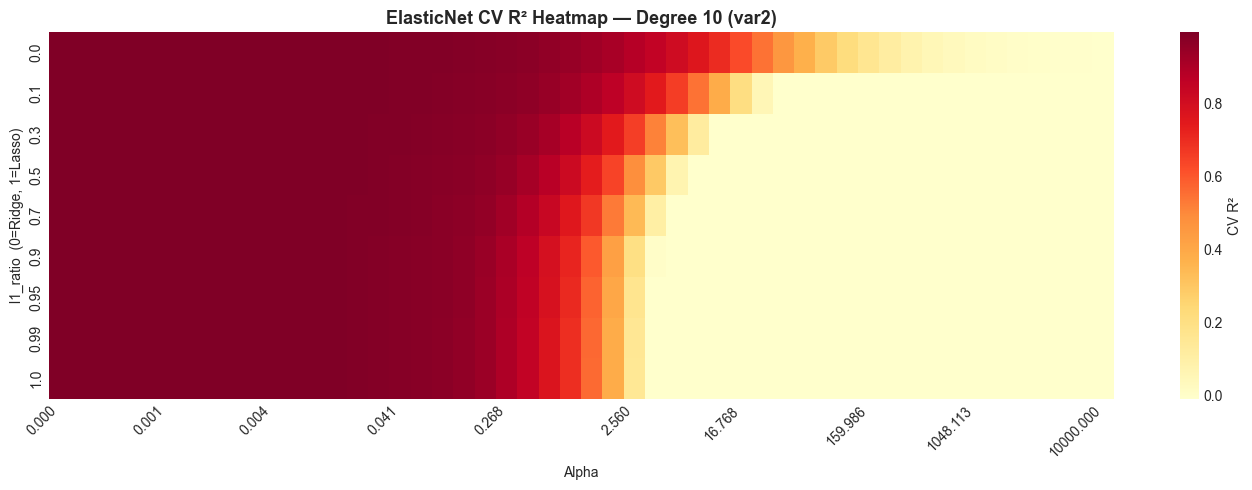

In [14]:
pivot = results_df.pivot(index='l1_ratio', columns='alpha', values='cv_r2')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'CV R²'})
ax.set_title(f'ElasticNet CV R² Heatmap — Degree {best_degree} (var2)', fontsize=13, fontweight='bold')
ax.set_xlabel('Alpha'); ax.set_ylabel('l1_ratio  (0=Ridge, 1=Lasso)')
n_ticks = 10
tick_pos = np.linspace(0, len(alphas)-1, n_ticks, dtype=int)
ax.set_xticks(tick_pos + 0.5)
ax.set_xticklabels([f'{alphas[i]:.3f}' for i in tick_pos], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../images/var2_elasticnet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

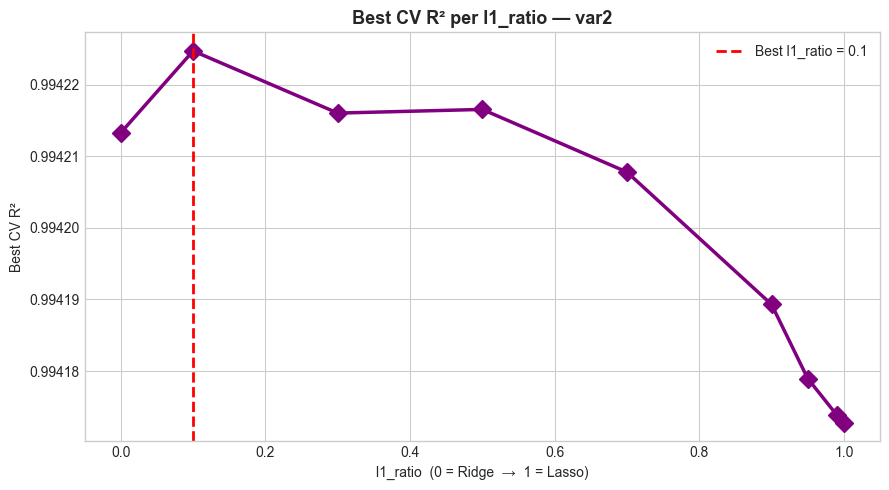


Best CV R² per l1_ratio:
 l1_ratio    cv_r2
     0.00 0.994213
     0.10 0.994225
     0.30 0.994216
     0.50 0.994217
     0.70 0.994208
     0.90 0.994189
     0.95 0.994179
     0.99 0.994174
     1.00 0.994173


In [15]:
best_per_l1 = results_df.groupby('l1_ratio')['cv_r2'].max().reset_index()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(best_per_l1['l1_ratio'], best_per_l1['cv_r2'], 'D-', color='purple', lw=2.5, ms=9)
ax.axvline(best_l1, color='red', ls='--', lw=2, label=f'Best l1_ratio = {best_l1}')
ax.set_title('Best CV R² per l1_ratio — var2', fontsize=13, fontweight='bold')
ax.set_xlabel('l1_ratio  (0 = Ridge  →  1 = Lasso)'); ax.set_ylabel('Best CV R²')
ax.legend()
plt.tight_layout()
plt.savefig('../images/var2_l1ratio_search.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBest CV R² per l1_ratio:')
print(best_per_l1.to_string(index=False))

## Step 7: Train Final Model with Best (degree, alpha, l1_ratio)

In [16]:
final_pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000, random_state=42))
])
final_pipe.fit(X_train, y_train)
y_pred_train = final_pipe.predict(X_train)

train_mse  = mean_squared_error(y_train, y_pred_train)
train_r2   = r2_score(y_train, y_pred_train)
n_features = final_pipe.named_steps['poly'].n_output_features_
coefs      = final_pipe.named_steps['model'].coef_
n_zero     = np.sum(coefs == 0)
n_nonzero  = np.sum(coefs != 0)

print('=== Final Model ===')
print(f'Degree           : {best_degree}')
print(f'Alpha            : {best_alpha:.6f}')
print(f'l1_ratio         : {best_l1}  (0=Ridge, 1=Lasso)')
print(f'Poly features    : {n_features}')
print(f'Non-zero coefs   : {n_nonzero}  ({n_nonzero/n_features*100:.1f}%)')
print(f'Zeroed-out coefs : {n_zero}  ({n_zero/n_features*100:.1f}%)')
print(f'Train MSE        : {train_mse:.6f}')
print(f'Train R²         : {train_r2:.6f}')

=== Final Model ===
Degree           : 10
Alpha            : 0.000655
l1_ratio         : 0.1  (0=Ridge, 1=Lasso)
Poly features    : 285
Non-zero coefs   : 253  (88.8%)
Zeroed-out coefs : 32  (11.2%)
Train MSE        : 0.162370
Train R²         : 0.996288


## Step 8: Residual Analysis

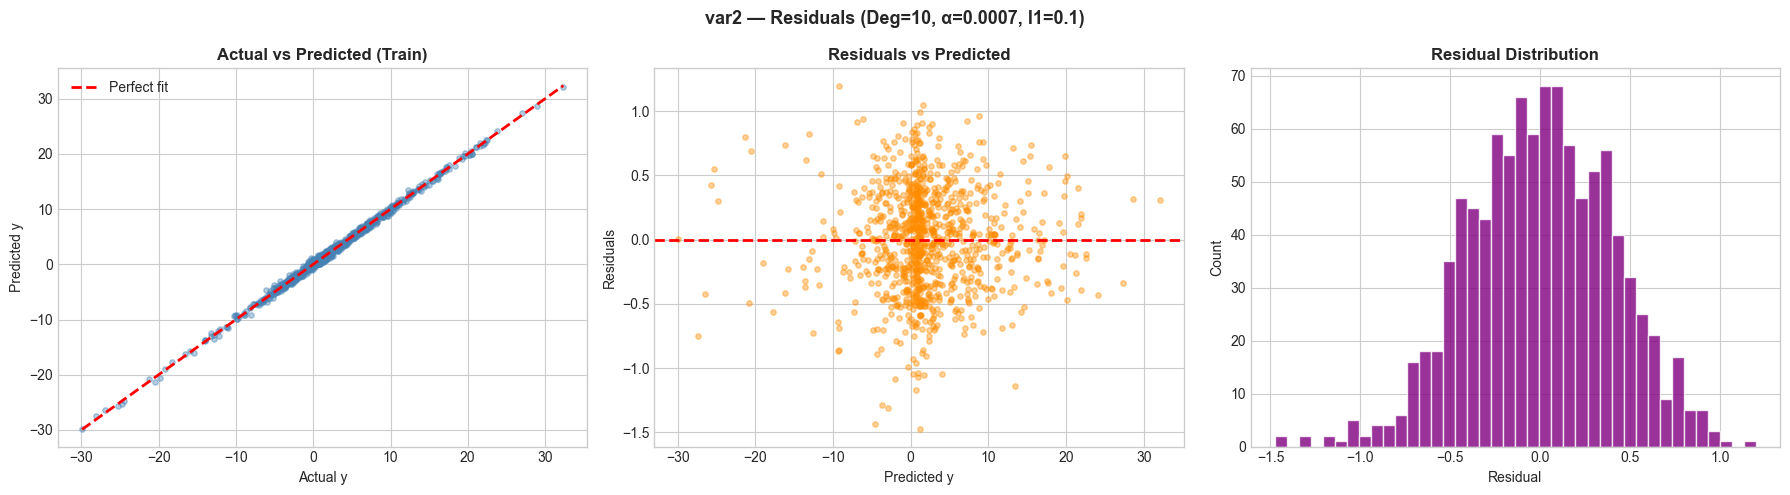

Residual mean: 0.000000  |  std: 0.402951


In [17]:
residuals = y_train - y_pred_train

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lo = min(y_train.min(), y_pred_train.min())
hi = max(y_train.max(), y_pred_train.max())

axes[0].scatter(y_train, y_pred_train, alpha=0.4, color='steelblue', s=15)
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
axes[0].set_title('Actual vs Predicted (Train)', fontweight='bold')
axes[0].set_xlabel('Actual y'); axes[0].set_ylabel('Predicted y'); axes[0].legend()

axes[1].scatter(y_pred_train, residuals, alpha=0.4, color='darkorange', s=15)
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].set_xlabel('Predicted y'); axes[1].set_ylabel('Residuals')

axes[2].hist(residuals, bins=40, color='purple', edgecolor='white', alpha=0.8)
axes[2].set_title('Residual Distribution', fontweight='bold')
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')

plt.suptitle(f'var2 — Residuals (Deg={best_degree}, α={best_alpha:.4f}, l1={best_l1})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Residual mean: {residuals.mean():.6f}  |  std: {residuals.std():.6f}')

## Step 9: Cross-Validation Summary of Final Model

In [18]:
cv_mse_final = -cross_val_score(final_pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_r2_final  =  cross_val_score(final_pipe, X_train, y_train, cv=kf, scoring='r2')

print('=== Final ElasticNet Model — 10-Fold CV ===')
print(f'CV MSE: {cv_mse_final.mean():.6f} +/- {cv_mse_final.std():.6f}')
print(f'CV R²:  {cv_r2_final.mean():.6f} +/- {cv_r2_final.std():.6f}')
print()
for i, (m, r) in enumerate(zip(cv_mse_final, cv_r2_final), 1):
    print(f'  Fold {i:2d}: MSE = {m:.6f}, R² = {r:.6f}')

=== Final ElasticNet Model — 10-Fold CV ===
CV MSE: 0.230232 +/- 0.041747
CV R²:  0.994225 +/- 0.002097

  Fold  1: MSE = 0.241192, R² = 0.993067
  Fold  2: MSE = 0.325581, R² = 0.989679
  Fold  3: MSE = 0.233491, R² = 0.993498
  Fold  4: MSE = 0.245136, R² = 0.994473
  Fold  5: MSE = 0.215518, R² = 0.996728
  Fold  6: MSE = 0.151895, R² = 0.997213
  Fold  7: MSE = 0.200086, R² = 0.995764
  Fold  8: MSE = 0.210008, R² = 0.992793
  Fold  9: MSE = 0.247858, R² = 0.995407
  Fold 10: MSE = 0.231558, R² = 0.993625


## Step 10: Coefficient Sparsity Analysis

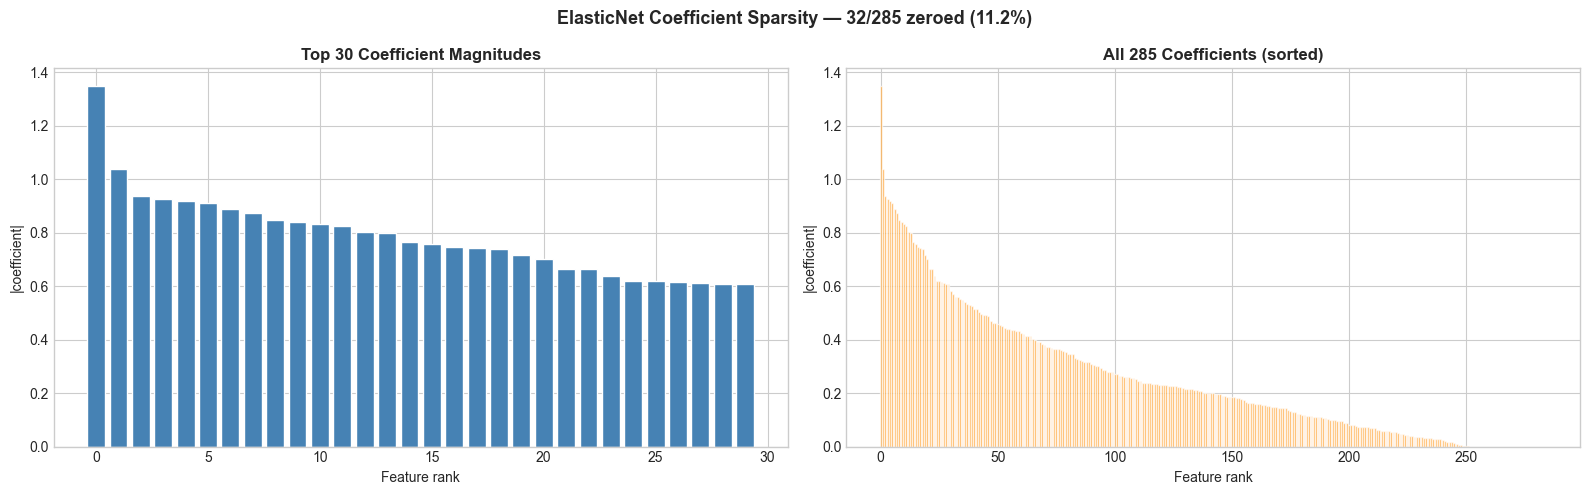

In [19]:
coef_abs   = np.abs(coefs)
sorted_idx = np.argsort(coef_abs)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_n = min(30, n_nonzero)
axes[0].bar(range(top_n), coef_abs[sorted_idx[:top_n]], color='steelblue', edgecolor='white')
axes[0].set_title(f'Top {top_n} Coefficient Magnitudes', fontweight='bold')
axes[0].set_xlabel('Feature rank'); axes[0].set_ylabel('|coefficient|')

axes[1].bar(range(n_features), coef_abs[sorted_idx], color='darkorange', edgecolor='white', alpha=0.7)
axes[1].set_title(f'All {n_features} Coefficients (sorted)', fontweight='bold')
axes[1].set_xlabel('Feature rank'); axes[1].set_ylabel('|coefficient|')

plt.suptitle(f'ElasticNet Coefficient Sparsity — {n_zero}/{n_features} zeroed ({n_zero/n_features*100:.1f}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_coeff_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Generate Test Predictions

Test predictions: (1000,)
Min: -29.9180, Max: 38.7600
Mean: 2.1981, Std: 7.2640


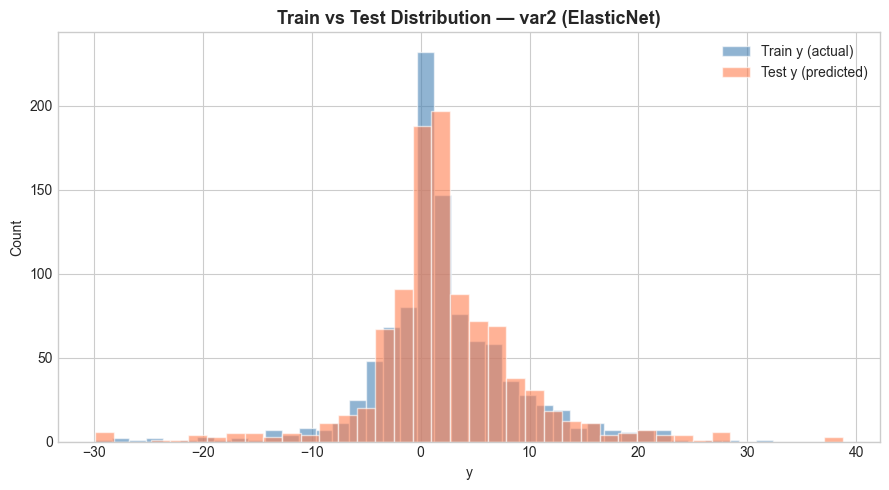

In [20]:
y_pred_test = final_pipe.predict(X_test)

print(f'Test predictions: {y_pred_test.shape}')
print(f'Min: {y_pred_test.min():.4f}, Max: {y_pred_test.max():.4f}')
print(f'Mean: {y_pred_test.mean():.4f}, Std: {y_pred_test.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_train, bins=40, alpha=0.6, color='steelblue', label='Train y (actual)', edgecolor='white')
ax.hist(y_pred_test, bins=40, alpha=0.6, color='coral', label='Test y (predicted)', edgecolor='white')
ax.set_title('Train vs Test Distribution — var2 (ElasticNet)', fontsize=13, fontweight='bold')
ax.set_xlabel('y'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.savefig('../images/var2_pred_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

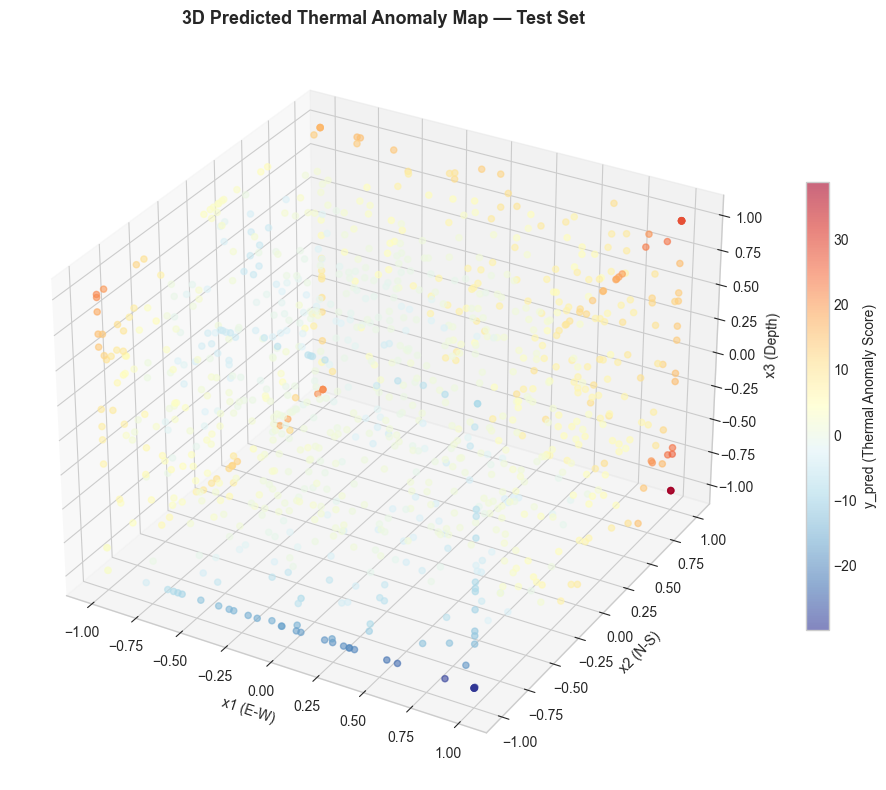

In [21]:
# 3D scatter of test predictions
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(test_df['x1'], test_df['x2'], test_df['x3'],
                c=y_pred_test, cmap='RdYlBu_r', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='y_pred (Thermal Anomaly Score)', shrink=0.6)
ax.set_xlabel('x1 (E-W)'); ax.set_ylabel('x2 (N-S)'); ax.set_zlabel('x3 (Depth)')
ax.set_title('3D Predicted Thermal Anomaly Map — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/var2_3d_test_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Save Submission File

In [22]:
submission = pd.DataFrame({'y': y_pred_test})
submission.to_csv('../predictions/BT2024195_pred_var2.csv', index=False)
print('Saved: BT2024195_pred_var2.csv')
print(f'Shape: {submission.shape}')
display(submission.head(10))

Saved: BT2024195_pred_var2.csv
Shape: (1000, 1)


,y
0,2.110634
1,2.614574
2,1.472788
3,0.960497
4,2.171348
5,-5.037679
6,-23.984356
7,1.017031
8,1.166358
9,4.773617


## Step 13: Final Model Summary

In [23]:
print('=' * 60)
print('       var2 — FINAL MODEL SUMMARY (ElasticNet)')
print('=' * 60)
print(f'  Problem          : Thermal Reservoir Mapping')
print(f'  Roll Number      : BT2024195')
print(f'  Features         : x1, x2, x3 (3 spatial vars)')
print(f'  Training rows    : {X_train.shape[0]}')
print(f'  Test rows        : {X_test.shape[0]}')
print(f'  Polynomial Deg   : {best_degree}')
print(f'  Alpha            : {best_alpha:.6f}')
print(f'  l1_ratio         : {best_l1}  (0=Ridge, 1=Lasso)')
print(f'  Poly Features    : {n_features}')
print(f'  Non-zero coefs   : {n_nonzero} / {n_features}')
print(f'  Train MSE        : {train_mse:.6f}')
print(f'  Train R²         : {train_r2:.6f}')
print(f'  CV MSE (10-fold) : {cv_mse_final.mean():.6f} +/- {cv_mse_final.std():.6f}')
print(f'  CV R²  (10-fold) : {cv_r2_final.mean():.6f} +/- {cv_r2_final.std():.6f}')
print('=' * 60)

       var2 — FINAL MODEL SUMMARY (ElasticNet)
  Problem          : Thermal Reservoir Mapping
  Roll Number      : BT2024195
  Features         : x1, x2, x3 (3 spatial vars)
  Training rows    : 1000
  Test rows        : 1000
  Polynomial Deg   : 10
  Alpha            : 0.000655
  l1_ratio         : 0.1  (0=Ridge, 1=Lasso)
  Poly Features    : 285
  Non-zero coefs   : 253 / 285
  Train MSE        : 0.162370
  Train R²         : 0.996288
  CV MSE (10-fold) : 0.230232 +/- 0.041747
  CV R²  (10-fold) : 0.994225 +/- 0.002097
